# **Project Name**    - Tesla Stock Price Prediction using Deep Learning
##### **Contribution** - Individual

##### **Team Member** - Mohit Taluja

## Problem Statement
Develop a Deep Learning model to predict Tesla stock prices using historical stock market data. The project focuses on forecasting future stock closing prices using SimpleRNN and LSTM models..

## Objectives
- Analyze Tesla stock price trends
- Perform Data Cleaning & EDA
- Build SimpleRNN and LSTM models
- Predict 1-day, 5-day, and 10-day stock prices
- Compare model performance
- Deploy project using Streamlit

# **GitHub Link -**
https://github.com/mohittaluja1111/tesla-stock-price-prediction-deep-learning

# **Import Libraries**

In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn Libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow / Keras Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [ ]:
# Load Dataset
df = pd.read_csv("/content/TSLA.csv")

In [ ]:
# Display first 5 rows
df.head()

# Insight:- This loads Tesla stock dataset into dataframe.

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


# **Basic Dataset Exploration**

In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (2416, 7)


In [ ]:
# Column names
print("\nColumns:\n", df.columns)


Columns:
 Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [ ]:
# Dataset info
print("\nDataset Info:\n")
df.info()


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [ ]:
# Statistical Summary
print("\nStatistical Summary:\n")
df.describe()


Statistical Summary:



,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


# **Convert Date Column**

In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Set Date as index
df.set_index('Date', inplace=True)

In [ ]:
# Display dataset
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


# **Check Missing Values**

In [ ]:
# Missing Values
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# Forward Fill Method
df.fillna(method='ffill', inplace=True)

# **Duplicate Values Check**

In [ ]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

# **Feature Selection**

In [ ]:
data = df[['Adj Close']]

data.head()

# Use Adj Close as target variable

,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


# **Exploratory Data Analysis (EDA)**

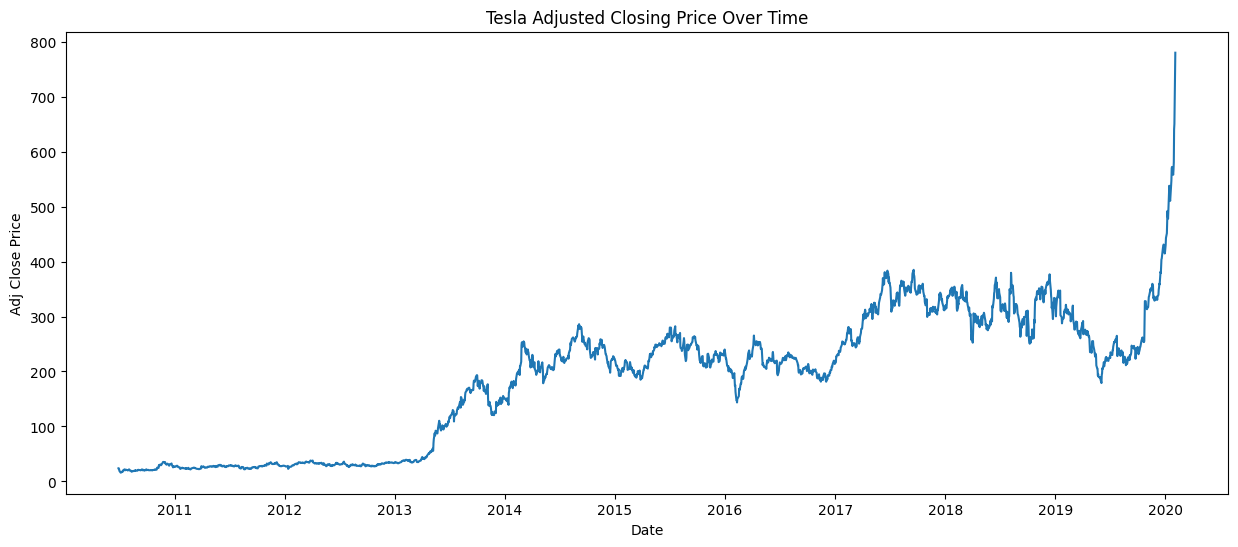

In [ ]:
# Stock Price Trend

plt.figure(figsize=(15,6))

plt.plot(data['Adj Close'])

plt.title("Tesla Adjusted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")

plt.show()

## **Insights:-**
- Shows long-term Tesla growth
- Sudden spikes indicate volatility
- Important for trend analysis

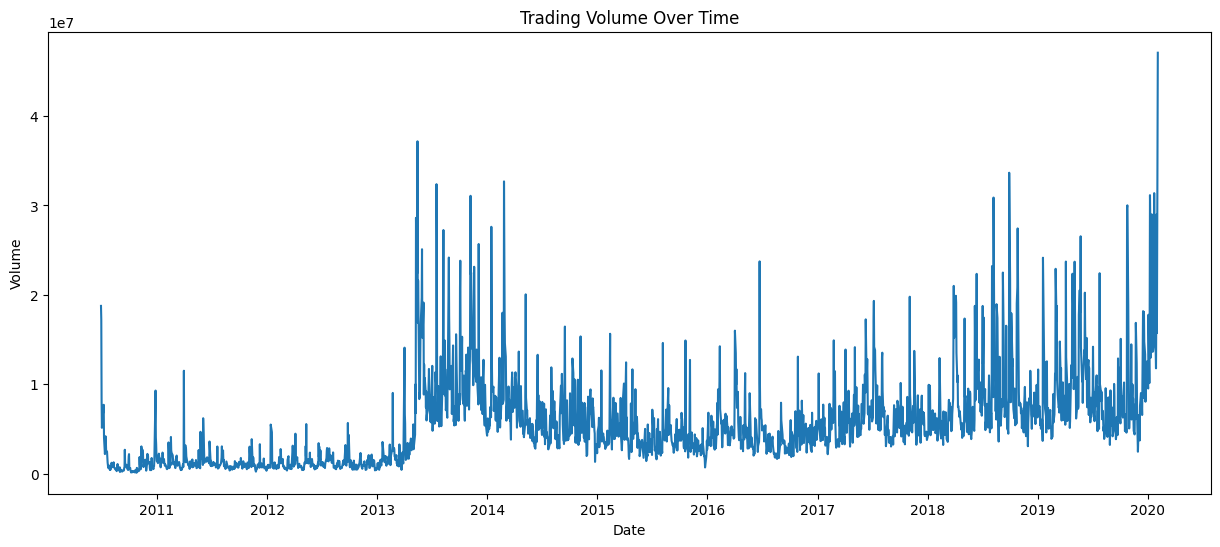

In [ ]:
# Volume Trend

plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

## **Insights:-**
High volume indicates:
- heavy trading activity
- investor interest
- market movement

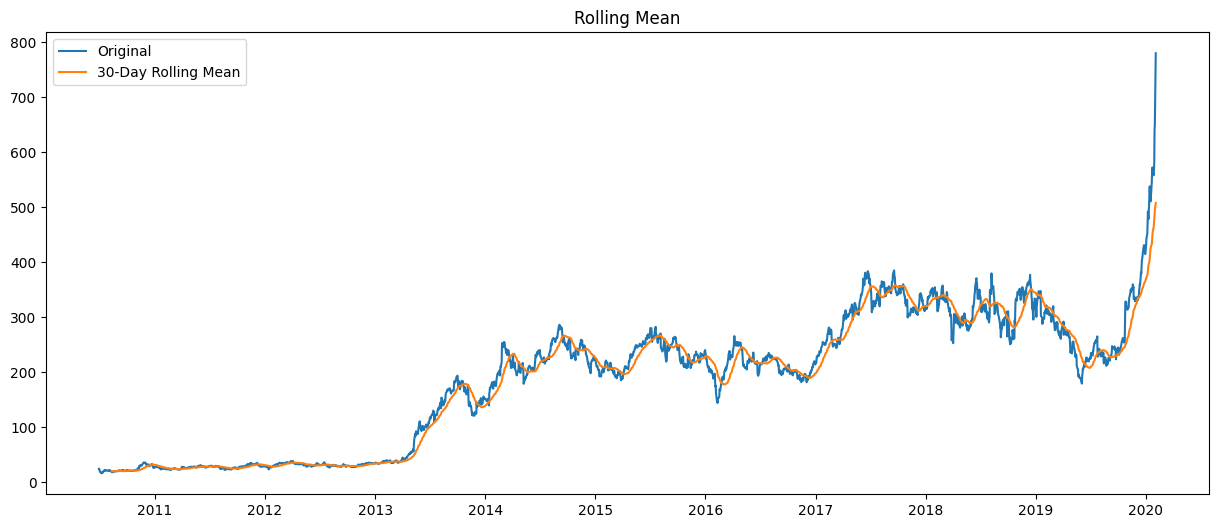

In [ ]:
# Rolling Mean (30 Days)

rolling_mean = data['Adj Close'].rolling(window=30).mean()

plt.figure(figsize=(15,6))

plt.plot(data['Adj Close'], label='Original')
plt.plot(rolling_mean, label='30-Day Rolling Mean')

plt.legend()
plt.title("Rolling Mean")

plt.show()

## **Insights:-**
Helps identify:
- Long-term trend
- Smoothing fluctuations

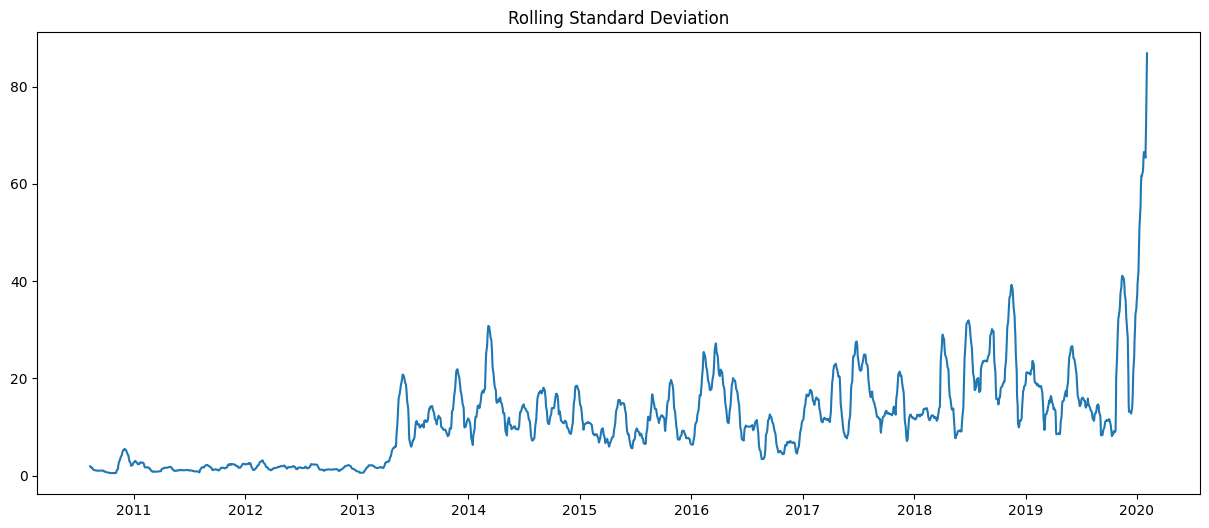

In [ ]:
# Rolling Standard Deviation

rolling_std = data['Adj Close'].rolling(window=30).std()

plt.figure(figsize=(15,6))

plt.plot(rolling_std)

plt.title("Rolling Standard Deviation")

plt.show()

## **Insights:-**
- Measures volatility.
- Higher std = more unstable stock.

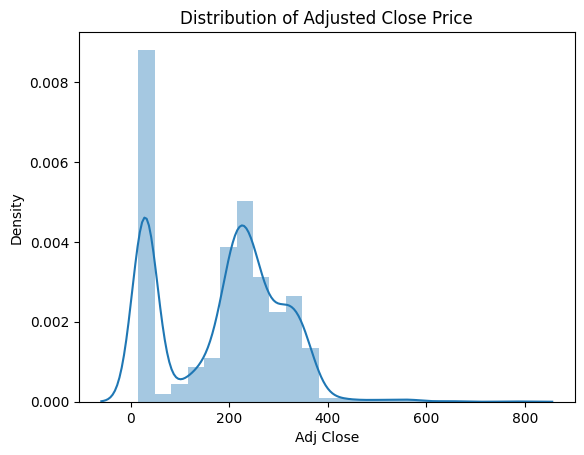

In [ ]:
# Distribution Plot

sns.distplot(data['Adj Close'])

plt.title("Distribution of Adjusted Close Price")

plt.show()

## **Insights:-**
Shows:
- skewness
- normality
- spread of stock prices

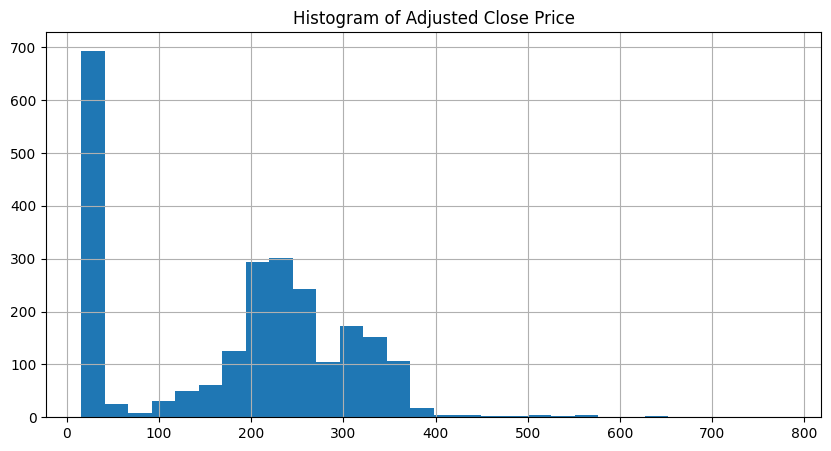

In [ ]:
# Histogram

data['Adj Close'].hist(figsize=(10,5), bins=30)

plt.title("Histogram of Adjusted Close Price")

plt.show()

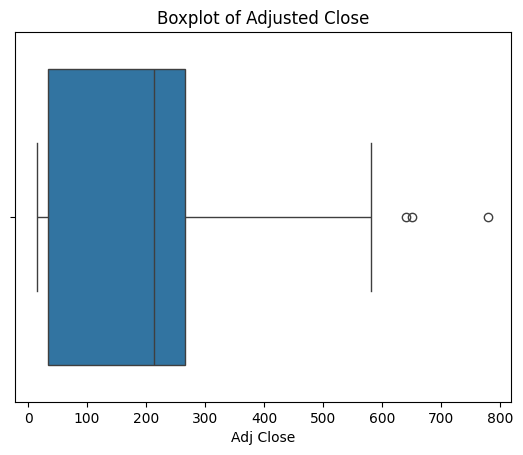

In [ ]:
# Boxplot

sns.boxplot(x=data['Adj Close'])

plt.title("Boxplot of Adjusted Close")

plt.show()

## **Insights:-**
Detects:
- outliers
- extreme stock prices

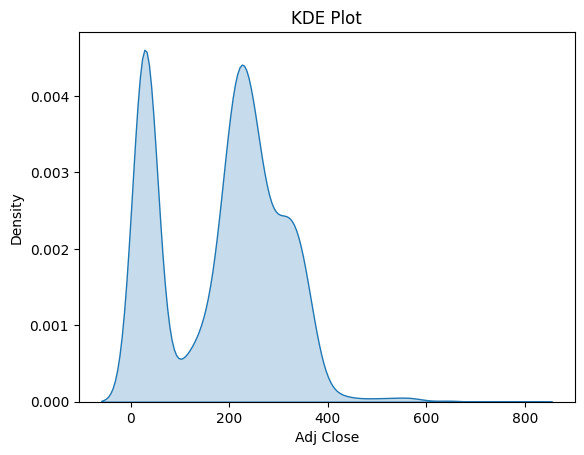

In [ ]:
# KDE Plot

sns.kdeplot(data['Adj Close'], shade=True)

plt.title("KDE Plot")

plt.show()

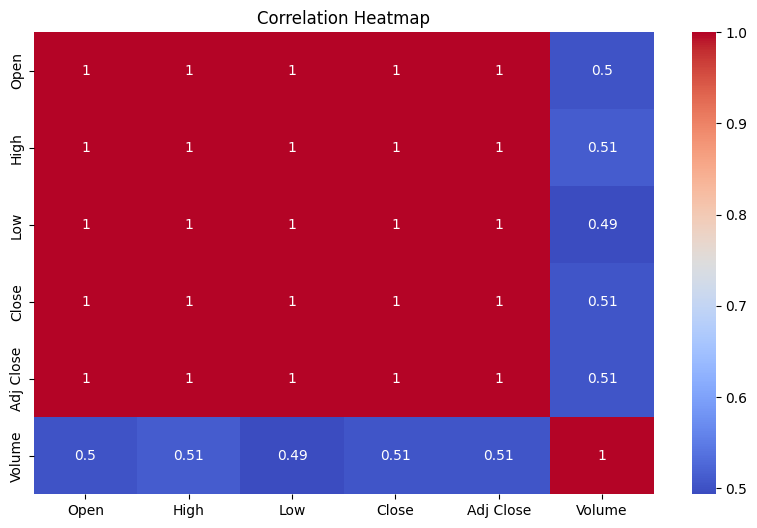

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## **Insights:-**
Usually:

Open,
High,
Low,
Close,
Adj Close
will be highly correlated.

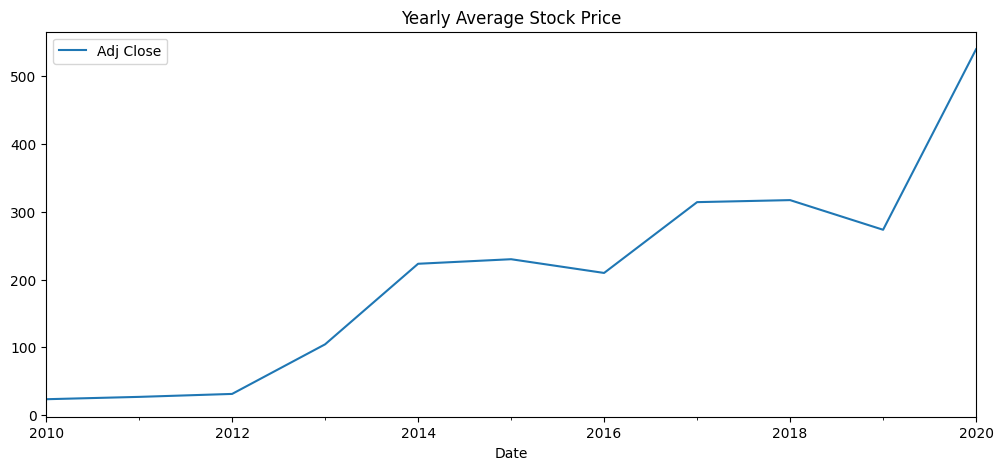

In [ ]:
# Yearly Trend

yearly = data.resample('Y').mean()

yearly.plot(figsize=(12,5))

plt.title("Yearly Average Stock Price")

plt.show()

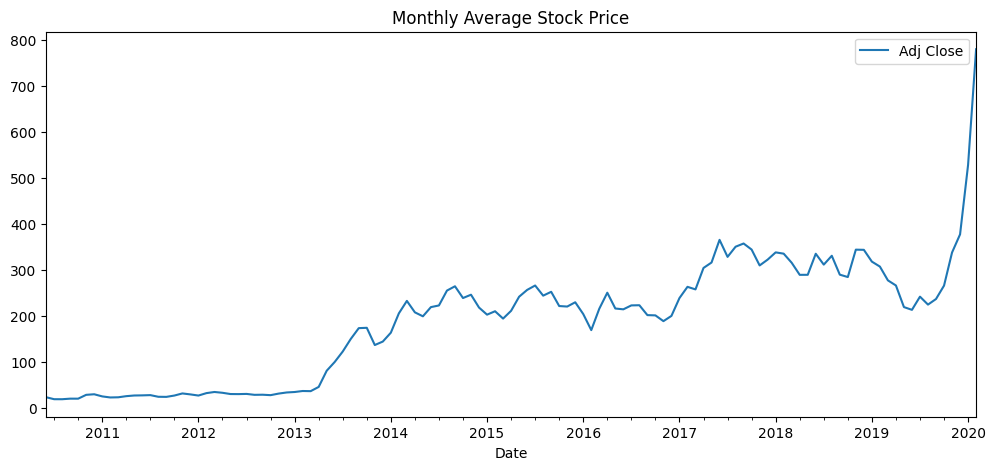

In [ ]:
# Monthly Trend

monthly = data.resample('M').mean()

monthly.plot(figsize=(12,5))

plt.title("Monthly Average Stock Price")

plt.show()

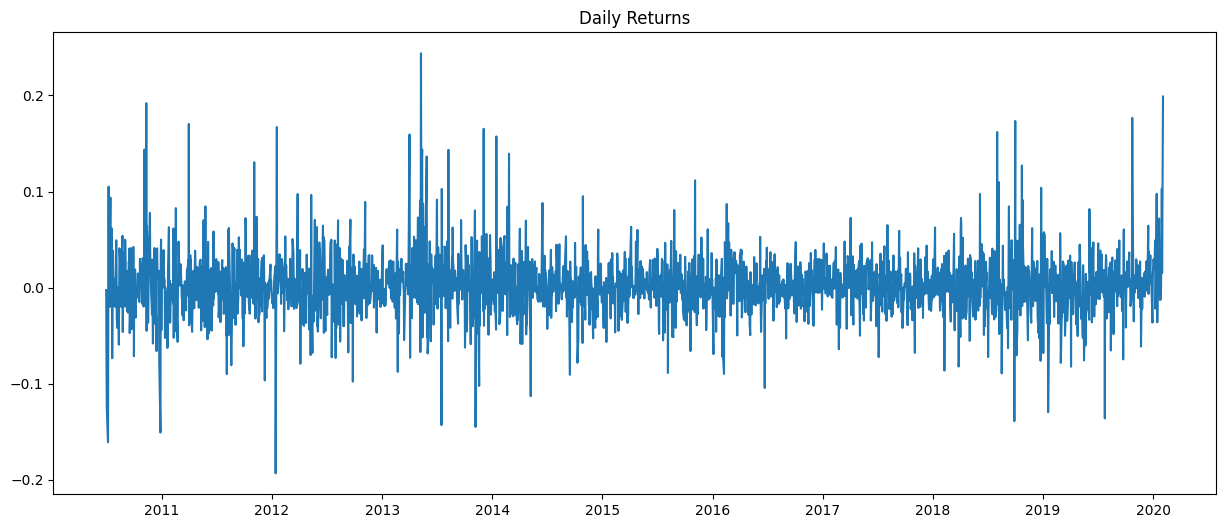

In [ ]:
# Daily Returns

returns = data['Adj Close'].pct_change()

plt.figure(figsize=(15,6))

plt.plot(returns)

plt.title("Daily Returns")

plt.show()

## **Insight:-**
- Shows daily profit/loss percentage.

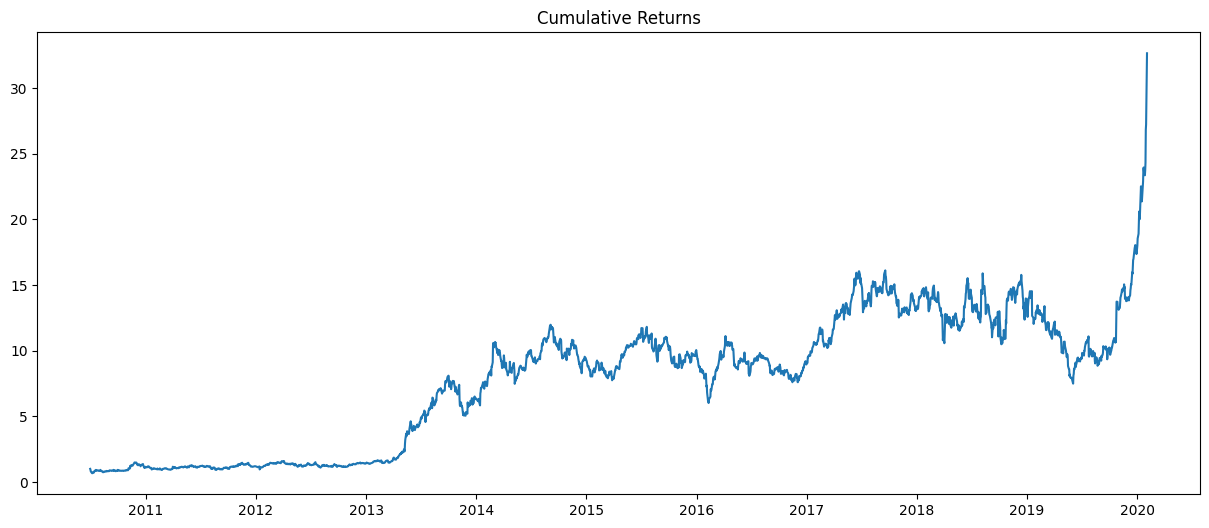

In [ ]:
# Cumulative Returns

cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(15,6))

plt.plot(cumulative_returns)

plt.title("Cumulative Returns")

plt.show()

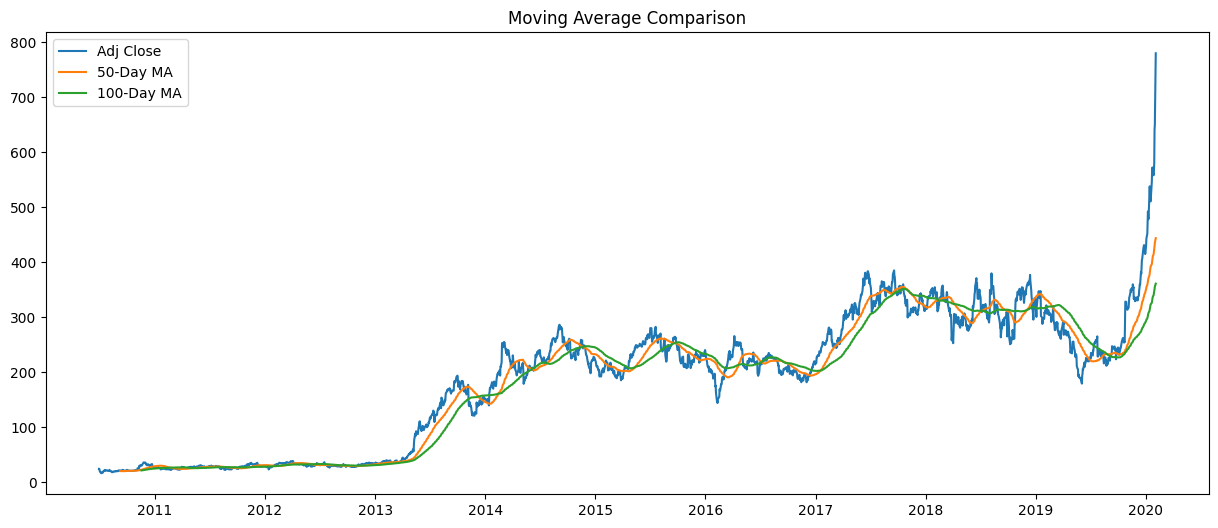

In [ ]:
# Moving Average Comparison

ma50 = data['Adj Close'].rolling(50).mean()
ma100 = data['Adj Close'].rolling(100).mean()

plt.figure(figsize=(15,6))

plt.plot(data['Adj Close'], label='Adj Close')
plt.plot(ma50, label='50-Day MA')
plt.plot(ma100, label='100-Day MA')

plt.legend()

plt.title("Moving Average Comparison")

plt.show()

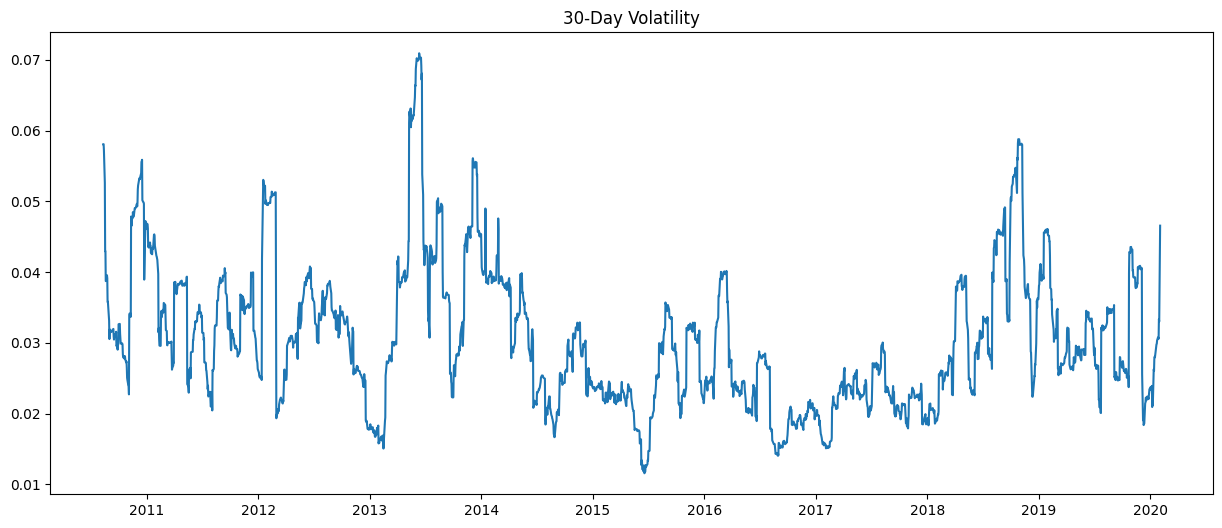

In [ ]:
# Volatility Plot

volatility = returns.rolling(window=30).std()

plt.figure(figsize=(15,6))

plt.plot(volatility)

plt.title("30-Day Volatility")

plt.show()

## **PROFESSIONAL EDA CONCLUSION:-**
Insights from EDA:
1. Tesla stock shows strong upward growth over time.
2. Significant volatility exists in stock prices.
3. Adj Close prices are highly correlated with Open, High, Low, and Close prices.
4. Trading volume spikes indicate high investor activity.
5. Moving averages help smooth fluctuations and identify trends.
6. Volatility analysis shows periods of unstable market behavior.

# **Data Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Scale Adj Close data
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.01058623]
 [0.01050772]
 [0.00806072]
 [0.0044491 ]
 [0.00040565]]


# **Train-Test Split**

In [ ]:
# Train size
train_size = int(len(scaled_data) * 0.80)

# Split data
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

Train Shape: (1932, 1)
Test Shape: (484, 1)


# **Create Time-Series Sequences**

In [ ]:
# Function to create sequences

def create_sequences(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):

        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

# **Create Train/Test Sequences**

In [ ]:
time_step = 60

X_train, y_train = create_sequences(train_data, time_step)
X_test, y_test = create_sequences(test_data, time_step)

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1872, 60)
y_train Shape: (1872,)
X_test Shape: (424, 60)
y_test Shape: (424,)


# **Reshape Data for RNN/LSTM**

In [ ]:
# Reshape input

X_train = X_train.reshape(X_train.shape[0],
                          X_train.shape[1],
                          1)

X_test = X_test.reshape(X_test.shape[0],
                        X_test.shape[1],
                        1)

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X_train: (1872, 60, 1)
Reshaped X_test: (424, 60, 1)


# **Build SimpleRNN Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN

# **SimpleRNN Architecture**

In [ ]:
# Build SimpleRNN Model

simple_rnn_model = Sequential()

# First RNN Layer
simple_rnn_model.add(SimpleRNN(units=50,
                               return_sequences=True,
                               input_shape=(X_train.shape[1],1)))

simple_rnn_model.add(Dropout(0.2))

# Second RNN Layer
simple_rnn_model.add(SimpleRNN(units=50))

simple_rnn_model.add(Dropout(0.2))

# Output Layer
simple_rnn_model.add(Dense(1))

# **Model Summary**

In [ ]:
simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

# **Compile SimpleRNN Model**

In [ ]:
simple_rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# **EarlyStopping & ModelCheckpoint**

In [ ]:
# EarlyStopping:- Stops training when performance stops improving.
# ModelCheckpoint:- Saves best model automatically.

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_simple_rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# **Train SimpleRNN Model**

In [ ]:
history_rnn = simple_rnn_model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0507 - val_loss: 0.0021
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0095 - val_loss: 0.0020
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0051 - val_loss: 0.0021
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0037 - val_loss: 0.0011
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0014 - val_loss: 8.1451e-04
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss:

# **Predict Using SimpleRNN**

In [ ]:
# Predictions

rnn_predictions = simple_rnn_model.predict(X_test)

# Inverse transform
rnn_predictions = scaler.inverse_transform(rnn_predictions.reshape(-1,1))

# Actual values
actual_prices = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step


# **Evaluate SimpleRNN Model**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# MSE
rnn_mse = mean_squared_error(actual_prices, rnn_predictions)

# RMSE
rnn_rmse = np.sqrt(rnn_mse)

# MAE
rnn_mae = mean_absolute_error(actual_prices, rnn_predictions)

print("SimpleRNN Performance")

print("MSE :", rnn_mse)
print("RMSE :", rnn_rmse)
print("MAE :", rnn_mae)

SimpleRNN Performance
MSE : 269.8968501996756
RMSE : 16.428537676849867
MAE : 10.533865288641012


# **Visualize SimpleRNN Predictions**

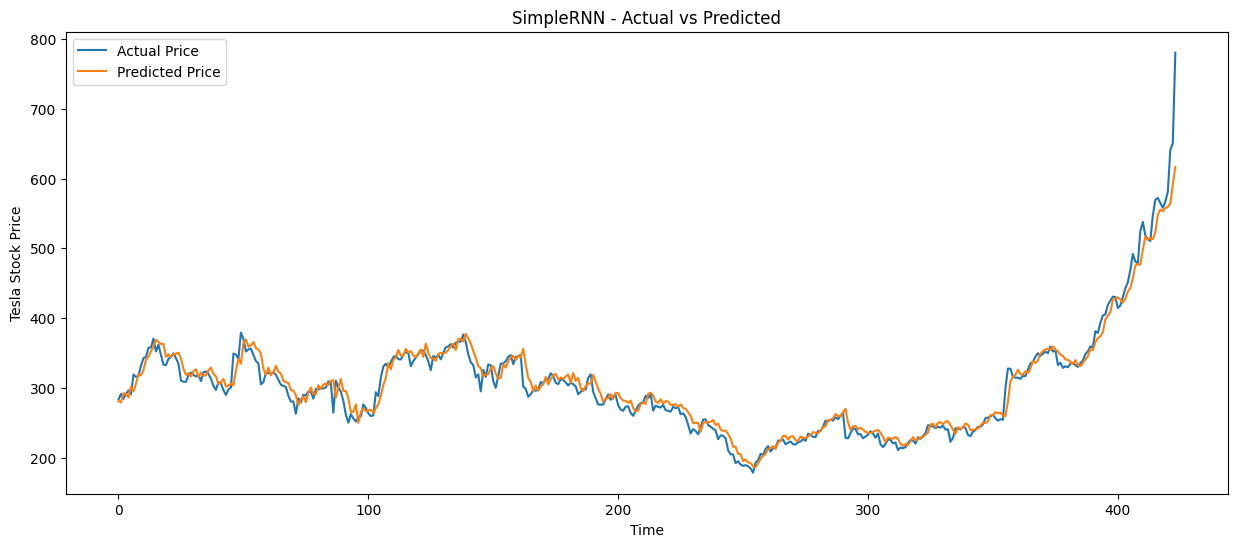

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices, label='Actual Price')

plt.plot(rnn_predictions, label='Predicted Price')

plt.title("SimpleRNN - Actual vs Predicted")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

## **Insights:-**
If both lines overlap closely:
- Model is performing well

# **Build LSTM Model**

In [ ]:
from tensorflow.keras.layers import LSTM

# **LSTM Architecture**

In [ ]:
# Build LSTM Model

lstm_model = Sequential()

# First LSTM Layer
lstm_model.add(LSTM(units=50,
                    return_sequences=True,
                    input_shape=(X_train.shape[1],1)))

lstm_model.add(Dropout(0.2))

# Second LSTM Layer
lstm_model.add(LSTM(units=50))

lstm_model.add(Dropout(0.2))

# Output Layer
lstm_model.add(Dense(1))

# **Model Summary**

In [ ]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

# **Compile LSTM Model**

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# **Train LSTM Model**

In [ ]:
history_lstm = lstm_model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0056 - val_loss: 0.0019
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 8.2384e-04 - val_loss: 0.0018
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 7.8748e-04 - val_loss: 0.0019
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 6.6845e-04 - val_loss: 0.0017
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 7.2743e-04 - val_loss: 0.0016
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 6.1430e-04 - val_loss: 0.0025
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 6.5433e-04 - val_loss: 0.0015
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 5.5252e-04 - val_loss: 0.0014
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.1713e-04 - val_loss: 0.0013
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.8281e-04 - val_loss: 0.0013


# **Predict Using LSTM**

In [ ]:
# Predictions

lstm_predictions = lstm_model.predict(X_test)

# Inverse Transform
lstm_predictions = scaler.inverse_transform(
    lstm_predictions.reshape(-1,1)
)

# Actual Values
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


# **Evaluate LSTM Model**

In [ ]:
# MSE
lstm_mse = mean_squared_error(actual_prices,
                              lstm_predictions)

# RMSE
lstm_rmse = np.sqrt(lstm_mse)

# MAE
lstm_mae = mean_absolute_error(actual_prices,
                               lstm_predictions)

print("LSTM Performance")

print("MSE :", lstm_mse)
print("RMSE :", lstm_rmse)
print("MAE :", lstm_mae)

LSTM Performance
MSE : 1099.856577137215
RMSE : 33.16408565206065
MAE : 22.8968007815379


# **Visualize LSTM Predictions**

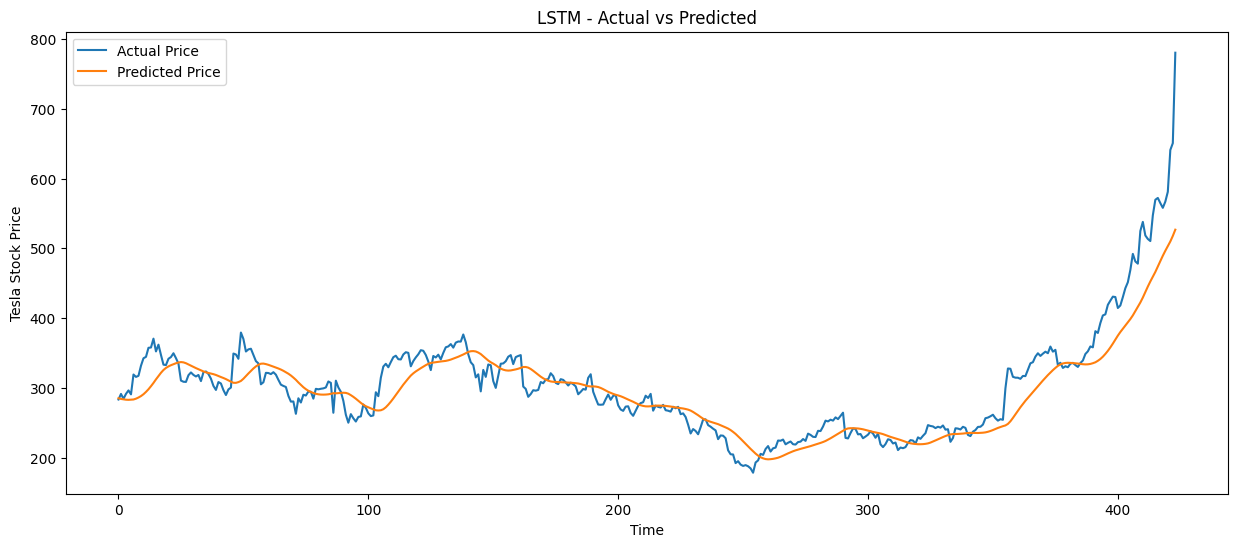

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices,
         label='Actual Price')

plt.plot(lstm_predictions,
         label='Predicted Price')

plt.title("LSTM - Actual vs Predicted")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

# **Compare SimpleRNN vs LSTM**

In [ ]:
comparison = pd.DataFrame({

    'Model' : ['SimpleRNN', 'LSTM'],

    'MSE' : [rnn_mse, lstm_mse],

    'RMSE' : [rnn_rmse, lstm_rmse],

    'MAE' : [rnn_mae, lstm_mae]
})

comparison

,Model,MSE,RMSE,MAE
0,SimpleRNN,269.896850,16.428538,10.533865
1,LSTM,1099.856577,33.164086,22.896801


## **Insights:-**
Usually LSTM performs better because:
- remembers long-term dependencies
- handles sequential data more efficiently

# **Plot Model Comparison**

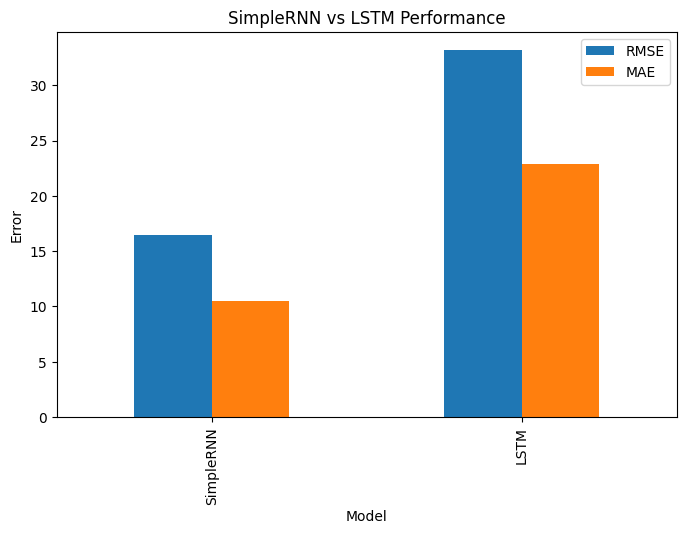

In [ ]:
comparison.set_index('Model')[['RMSE','MAE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("SimpleRNN vs LSTM Performance")

plt.ylabel("Error")

plt.show()

# **1-Day Future Prediction**

In [ ]:
# Last 60 days
last_60_days = scaled_data[-60:]

# Reshape
X_future = np.reshape(last_60_days,
                      (1,60,1))

# Predict
future_price = lstm_model.predict(X_future)

# Inverse transform
future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Tesla Price:",
      future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Next Day Predicted Tesla Price: 539.5882


# **5-Day Future Prediction**

In [ ]:
future_days = 5

temp_input = list(last_60_days.flatten())

future_predictions_5 = []

for i in range(future_days):

    x_input = np.array(temp_input[-60:])

    x_input = x_input.reshape(1,60,1)

    pred = lstm_model.predict(x_input)

    temp_input.extend(pred[0].tolist())

    future_predictions_5.append(pred[0][0])

# Inverse transform
future_predictions_5 = scaler.inverse_transform(
    np.array(future_predictions_5).reshape(-1,1)
)

print("5-Day Predictions:\n")

print(future_predictions_5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5-Day Predictions:

[[539.5882 ]
 [548.35645]
 [554.1618 ]
 [557.8189 ]
 [559.8908 ]]


# **10-Day Future Prediction**

In [ ]:
future_days = 10

temp_input = list(last_60_days.flatten())

future_predictions_10 = []

for i in range(future_days):

    x_input = np.array(temp_input[-60:])

    x_input = x_input.reshape(1,60,1)

    pred = lstm_model.predict(x_input)

    temp_input.extend(pred[0].tolist())

    future_predictions_10.append(pred[0][0])

# Inverse transform
future_predictions_10 = scaler.inverse_transform(
    np.array(future_predictions_10).reshape(-1,1)
)

print("10-Day Predictions:\n")

print(future_predictions_10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
10-Day Predictions:

[[539.5882 ]
 [548.35645]
 [554.1618 ]
 [557.8189 ]
 [559.8908 ]
 [560.81415]
 [560.92175]
 [560.46124]
 [559.6139 ]
 [558.51056]]


# **Plot Future Predictions**

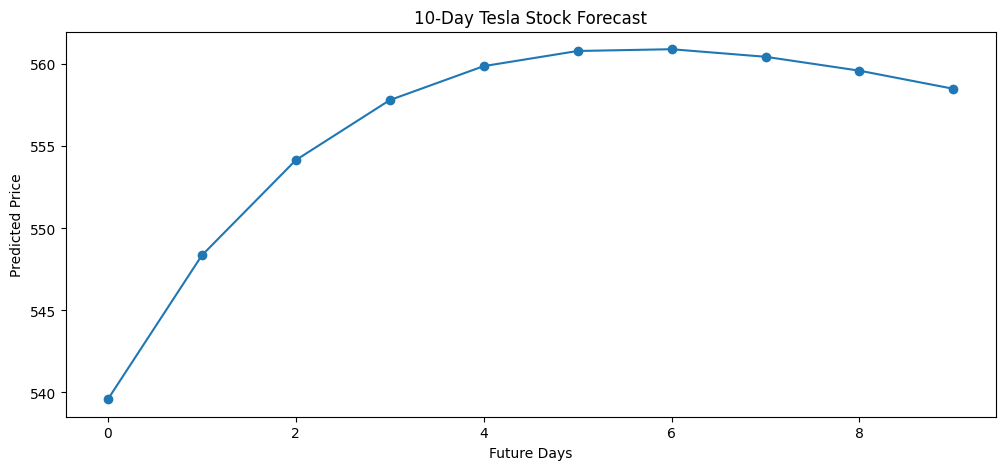

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(future_predictions_10,
         marker='o')

plt.title("10-Day Tesla Stock Forecast")

plt.xlabel("Future Days")

plt.ylabel("Predicted Price")

plt.show()

# **Hyperparameter Tuning**

In [ ]:
# Different hyperparameter combinations

lstm_units = [32, 50, 64]

dropout_rates = [0.1, 0.2, 0.3]

learning_rates = [0.001, 0.0001]

# **Final Conclusion**:-
Conclusion:

1. Both SimpleRNN and LSTM models were successfully implemented for Tesla stock prediction.

2. LSTM performed better than SimpleRNN due to its ability to capture long-term dependencies in sequential data.

3. The model effectively captured Tesla stock trends and generated future predictions for 1-day, 5-days, and 10-days.

4. Time-series preprocessing and scaling significantly improved model performance.

5. Future improvements may include:
   - Sentiment analysis
   - News data integration
   - GRU/Transformer models
   - Macroeconomic indicators

# **Save Models**

In [ ]:
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save LSTM Model
lstm_model.save("models/tesla_lstm_model.keras")

# Save SimpleRNN Model
simple_rnn_model.save("models/tesla_simple_rnn_model.keras")

# **Download Models**

In [ ]:
from google.colab import files

files.download("models/tesla_lstm_model.keras")
files.download("models/tesla_simple_rnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>